In [1]:
# Primero miramos como es el csv

import pandas as pd

muestra = pd.read_csv('DogMoveData.csv', nrows=5)
print(muestra)
print(muestra.columns.tolist())
print(muestra.dtypes)

   DogID  TestNum  t_sec   ABack_x   ABack_y   ABack_z   ANeck_x   ANeck_y  \
0     16        1   0.00  0.041504  0.938965 -0.015137 -0.067871 -0.510254   
1     16        1   0.01  0.041992  0.941895 -0.020020 -0.128906 -0.494141   
2     16        1   0.02  0.040527  0.939453 -0.004395 -0.158691 -0.480469   
3     16        1   0.03  0.021484  0.946289  0.007813 -0.122070 -0.486816   
4     16        1   0.04 -0.000977  0.951172  0.033691 -0.053711 -0.500000   

    ANeck_z    GBack_x    GBack_y   GBack_z   GNeck_x   GNeck_y    GNeck_z  \
0 -0.934570 -17.639161 -22.766115  7.446290 -7.934571  6.347657  13.427735   
1 -0.913086 -15.075685 -11.413575  4.821778 -3.906250  4.394532  16.540528   
2 -0.911133 -12.207032  -0.122070  2.807617 -0.488281 -1.953125  26.794435   
3 -0.880371  -9.460450   7.995606  1.586914  1.159668 -5.676270  38.085940   
4 -0.807129  -8.361817  14.587403 -1.037598  4.577637  4.089356  41.503909   

          Task       Behavior_1   Behavior_2   Behavior_3   Po

In [2]:
# Cargamos solo las 3 columnas de comportamiento, sin acelerometro,
# para poder inspeccionar como se combinan los Behavior_1/2/3

behaviors_check = pd.read_csv(
    'DogMoveData.csv',
    usecols=['Behavior_1', 'Behavior_2', 'Behavior_3'],
    dtype={'Behavior_1': 'category', 'Behavior_2': 'category', 'Behavior_3': 'category'},
)

print(f"Filas cargadas: {len(behaviors_check)}")

Filas cargadas: 10611068


In [4]:
# Analizamos los behaviors, para ver como se clasifican las filas y si combinan comportamientos

from IPython.display import display

targets = ['Trotting', 'Lying chest', 'Walking', 'Standing']

# Filas donde una de nuestras 4 clases objetivo aparece en Behavior_2 (el caso mas comun: 745.423 filas)
ejemplo_col2 = behaviors_check[behaviors_check['Behavior_2'].isin(targets)]
display(ejemplo_col2.head(10))

# Filas donde una clase objetivo aparece en Behavior_3 (el caso mas raro: 42.588 filas)
ejemplo_col3 = behaviors_check[behaviors_check['Behavior_3'].isin(targets)]
display(ejemplo_col3.head(10))

,Behavior_1,Behavior_2,Behavior_3
13989,Eating,Walking,<undefined>
13990,Eating,Walking,<undefined>
13991,Eating,Walking,<undefined>
13992,Eating,Walking,<undefined>
13993,Eating,Walking,<undefined>
13994,Eating,Walking,<undefined>
13995,Eating,Walking,<undefined>
13996,Eating,Walking,<undefined>
13997,Eating,Walking,<undefined>
13998,Eating,Walking,<undefined>


,Behavior_1,Behavior_2,Behavior_3
102341,Playing,Carrying object,Trotting
102342,Playing,Carrying object,Trotting
102343,Playing,Carrying object,Trotting
102344,Playing,Carrying object,Trotting
102345,Playing,Carrying object,Trotting
102346,Playing,Carrying object,Trotting
102347,Playing,Carrying object,Trotting
102348,Playing,Carrying object,Trotting
102349,Playing,Carrying object,Trotting
102350,Playing,Carrying object,Trotting


In [5]:
# Separamos las columnas que nos interesan y leemos el csv completo con esas columnas y los tipos de datos correctos

columnas_necesarias = ['DogID', 'TestNum', 't_sec', 'ABack_x', 'ABack_y', 'ABack_z', 'Behavior_1', 'Behavior_2', 'Behavior_3']

df_completo = pd.read_csv(
    'DogMoveData.csv',
    usecols=columnas_necesarias,
    dtype={
        'DogID': 'int32',
        'TestNum': 'int32',
        't_sec': 'float32',
        'ABack_x': 'float32',
        'ABack_y': 'float32',
        'ABack_z': 'float32',
        'Behavior_1': 'category',
        'Behavior_2': 'category',
        'Behavior_3': 'category',
    },
)

print(f"Filas totales leidas: {len(df_completo)}")

Filas totales leidas: 10611068


In [6]:
# Combinamos las 3 columnas de comportamiento en una sola, filtrando solo las clases objetivo

targets = ['Trotting', 'Lying chest', 'Walking', 'Standing']
cols_behavior = ['Behavior_1', 'Behavior_2', 'Behavior_3']

es_objetivo = df_completo[cols_behavior].isin(targets)

# de las 3 columnas, coge el valor de la que coincide con una clase objetivo
# (a lo sumo una por fila, ya lo comprobamos antes)
df_completo['behavior_final'] = df_completo[cols_behavior].where(es_objetivo).bfill(axis=1).iloc[:, 0]

df_filtrado = df_completo[df_completo['behavior_final'].notna()].copy()
del df_completo

df_filtrado['behavior_final'] = df_filtrado['behavior_final'].astype('category')

print(f"Filas filtradas: {len(df_filtrado)}")
print(df_filtrado['behavior_final'].value_counts())

Filas filtradas: 3714526
behavior_final
Lying chest    1129902
Standing       1027710
Walking         783035
Trotting        773879
Name: count, dtype: int64


In [7]:
print("Perros distintos con al menos una fila, por clase:")
print(df_filtrado.groupby('behavior_final', observed=True)['DogID'].nunique())

Perros distintos con al menos una fila, por clase:
behavior_final
Lying chest    45
Standing       45
Trotting       45
Walking        45
Name: DogID, dtype: int64


In [8]:
# Deteccion de runs (tramos temporalmente contiguos con la misma etiqueta).
#
# Necesario por tres motivos distintos:
#  1. El dataset esta anotado post-hoc a partir de video: un comportamiento
#     dura lo que dure en la realidad, no encaja en ningun grid fijo. Para
#     construir ventanas de 1s con una unica etiqueta hay que saber donde
#     empieza y termina cada tramo de comportamiento constante.
#  2. Al filtrar a solo las 4 clases objetivo, el propio filtrado introduce
#     huecos artificiales: si el perro pasa de Standing a Sniffing y vuelve
#     a Standing 8s despues, las dos partes de Standing quedan "seguidas"
#     en la tabla filtrada aunque no lo sean en el tiempo real.
#  3. De paso, sirve para detectar huecos de muestreo genuinos del propio
#     dispositivo (perdida de muestras), independientes de los dos motivos
#     anteriores.
#
# Esto es exclusivo de la fase de preparacion de datos de entrenamiento a
# partir de un dataset publico etiquetado. El sistema real desplegado no
# "detecta runs de comportamiento": la etiqueta es precisamente lo que el
# clasificador ya entrenado va a predecir, no algo disponible en produccion.

import numpy as np

df_filtrado = df_filtrado.sort_values(['DogID', 'TestNum', 't_sec']).reset_index(drop=True)

delta_t = df_filtrado.groupby(['DogID', 'TestNum'], observed=True)['t_sec'].diff()

# a 100 Hz el intervalo esperado entre muestras es 0.01s (con margen por precision float32)
salto_tiempo = ~np.isclose(delta_t, 0.01, atol=0.001)
cambio_behavior = df_filtrado['behavior_final'].ne(df_filtrado['behavior_final'].shift())

nuevo_run = salto_tiempo | cambio_behavior
nuevo_run.iloc[0] = True

df_filtrado['run_id'] = nuevo_run.cumsum()

print(f"Runs detectados: {df_filtrado['run_id'].nunique()}")

# de esos saltos, cuantos son huecos reales dentro de una sesion (no el inicio de una sesion nueva)
saltos_internos = salto_tiempo & delta_t.notna()
print(f"Saltos de muestreo dentro de una sesion (no al inicio): {saltos_internos.sum()}")

Runs detectados: 3645
Saltos de muestreo dentro de una sesion (no al inicio): 3583


In [9]:
gaps = delta_t[saltos_internos]

print(gaps.describe())
print()
print(f"Huecos pequeños (<1s, probable perdida de pocas muestras del dispositivo): {(gaps < 1.0).sum()}")
print(f"Huecos grandes (>=1s, probable comportamiento intermedio filtrado): {(gaps >= 1.0).sum()}")

count    3583.000000
mean       12.945871
std        38.298969
min         0.019958
25%         1.115044
50%         2.459961
75%         6.819977
max       604.060059
Name: t_sec, dtype: float64

Huecos pequeños (<1s, probable perdida de pocas muestras del dispositivo): 788
Huecos grandes (>=1s, probable comportamiento intermedio filtrado): 2795


In [10]:
# Una vez analizados los datos para ver con qiue trabajar, se adaptan al comportamiento de los datos que se usaran para la infencia
# Por un lado, el VeDBA se calcula a partir de la componente dinamica, por lo que aqui hacemos lo mismo y separamos la parte dinamica del dato crudo mediante una media movil hacia atra de 2 s
# Ademas, caclulamos el pitch y roll a partir de la componente estatica
# Tener en cuenta tambien la frecuencia de muestreo. El dataset original es a 100 Hz, sin embargo, el dispositivo muestrea a 12.5 Hz, por lo que hay que decimar el dato crudo en un factor 8

from scipy.signal import decimate

ODR_NATIVO = 100.0
FACTOR_DECIMADO = 8  # 100 Hz a 12.5 Hz
ODR_OBJETIVO = ODR_NATIVO / FACTOR_DECIMADO

VENTANA_STATIC_S = 2.0
MIN_MUESTRAS_RUN = 40
MIN_MUESTRAS_VENTANA = 8


def separar_estatica_dinamica(accel, odr, ventana_s):
    """Media movil causal (hacia atras), identica a decodificar_sector_imu()."""
    n = max(int(round(ventana_s * odr)), 1)
    estatica = pd.DataFrame(accel).rolling(window=n, min_periods=1).mean().to_numpy()
    dinamica = accel - estatica
    return estatica, dinamica


def calcular_pitch_roll(estatica):
    """pitch = atan2(static_x, sqrt(static_y^2+static_z^2)); roll = atan2(static_y, sqrt(static_x^2+static_z^2))."""
    x, y, z = estatica[:, 0], estatica[:, 1], estatica[:, 2]
    pitch = np.degrees(np.arctan2(x, np.sqrt(y**2 + z**2)))
    roll = np.degrees(np.arctan2(y, np.sqrt(x**2 + z**2)))
    return pitch, roll


def calcular_vedba(dinamica):
    """VeDBA = norma L2 de la componente dinamica: sqrt(din_x^2+din_y^2+din_z^2)."""
    return np.sqrt((dinamica ** 2).sum(axis=1))

In [11]:
# Ahora procesmos los datos por run, generando ventanas de 1s con los indicadores calculados a partir de la componente dinamica y estatica del acelerometro

def procesar_run(grupo):
    accel_100hz = grupo[['ABack_x', 'ABack_y', 'ABack_z']].to_numpy() # Cojo los 3 ejes crudos a 100 Hz

    if len(accel_100hz) < MIN_MUESTRAS_RUN:
        return []

    # Remuestreo con un paso-bajo + diezmado a 12,5 Hz (factor 8)
    accel_12_5hz = decimate(accel_100hz, q=FACTOR_DECIMADO, axis=0, zero_phase=True)

    # Separo componentes y calculos indicadores
    estatica, dinamica = separar_estatica_dinamica(accel_12_5hz, ODR_OBJETIVO, VENTANA_STATIC_S)
    pitch, roll = calcular_pitch_roll(estatica)
    vedba = calcular_vedba(dinamica)

    # bucket por segundo relativo al inicio del run (mismo criterio que indicadores_imu_1s)
    tiempo_s = np.arange(len(accel_12_5hz)) / ODR_OBJETIVO
    segundo = np.floor(tiempo_s).astype(int)

    # Calculo los indicadores por ventana de 1s
    ventanas = []
    for seg in np.unique(segundo):
        mask = segundo == seg
        n_muestras = mask.sum()

        # NOTA: indicadores_imu_1s solo exige n_muestras > 0. Aqui exigimos MIN_MUESTRAS_VENTANA=8 como
        # decision deliberada de la PoC: con datos abundantes no compensa aceptar ventanas
        # de 1-2 muestras que solo anadirian ruido al entrenamiento.
        if n_muestras < MIN_MUESTRAS_VENTANA:
            continue

        ventanas.append({
            'dog_id': grupo['DogID'].iloc[0],
            'test_num': grupo['TestNum'].iloc[0],
            'run_id': grupo['run_id'].iloc[0],
            'behavior': grupo['behavior_final'].iloc[0],
            'n_muestras': n_muestras,
            'vedba_mean': vedba[mask].mean(),
            'vedba_max': vedba[mask].max(),
            'pitch_mean': pitch[mask].mean(),
            'roll_mean': roll[mask].mean(),
        })
    return ventanas

todas_ventanas = []
for _, grupo in df_filtrado.groupby('run_id'):
    todas_ventanas.extend(procesar_run(grupo))

ventanas_df = pd.DataFrame(todas_ventanas)

print(f"Runs procesados: {df_filtrado['run_id'].nunique()}")
print(f"Ventanas de 1s generadas: {len(ventanas_df)}")

Runs procesados: 3645
Ventanas de 1s generadas: 36769


In [12]:
print("Ventanas por clase:")
print(ventanas_df['behavior'].value_counts())
print()
print("Perros distintos con al menos una ventana, por clase:")
print(ventanas_df.groupby('behavior')['dog_id'].nunique())

Ventanas por clase:
behavior
Lying chest    11272
Standing       10185
Walking         7689
Trotting        7623
Name: count, dtype: int64

Perros distintos con al menos una ventana, por clase:
behavior
Lying chest    45
Standing       45
Trotting       45
Walking        45
Name: dog_id, dtype: int64


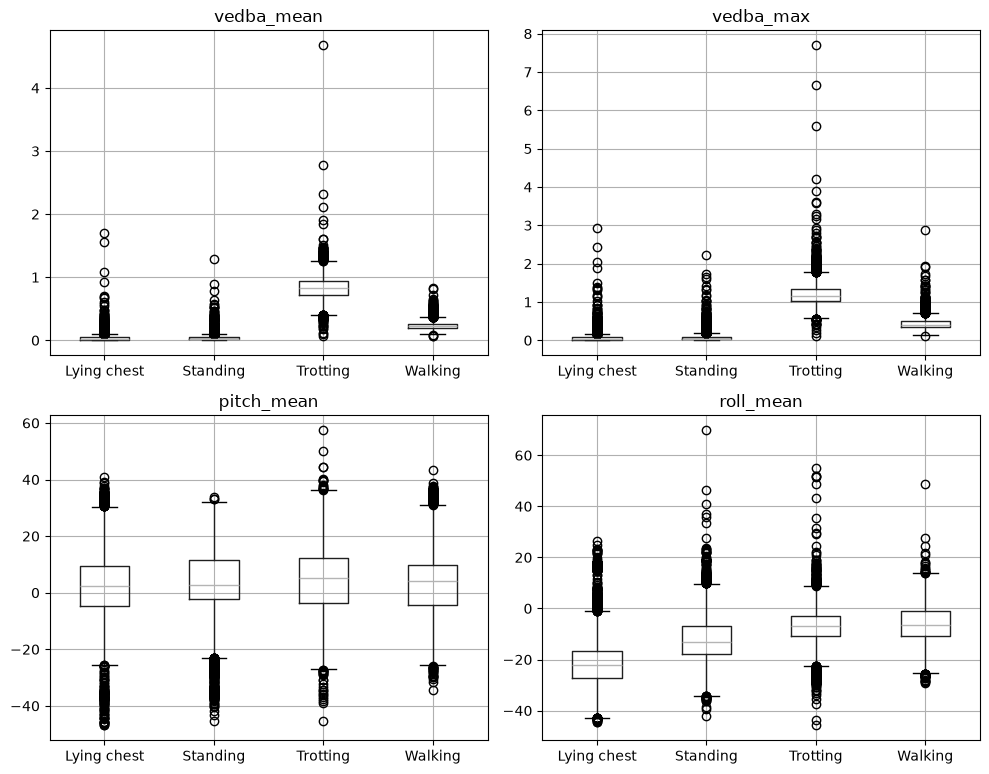

In [13]:
# Tras generar las metricas acorde a como se hace en la base de datos, vemos los resultados
# Visualizamos con boxplots para ver las distribuciones

import matplotlib.pyplot as plt

features = ['vedba_mean', 'vedba_max', 'pitch_mean', 'roll_mean']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feat in zip(axes.ravel(), features):
    ventanas_df.boxplot(column=feat, by='behavior', ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

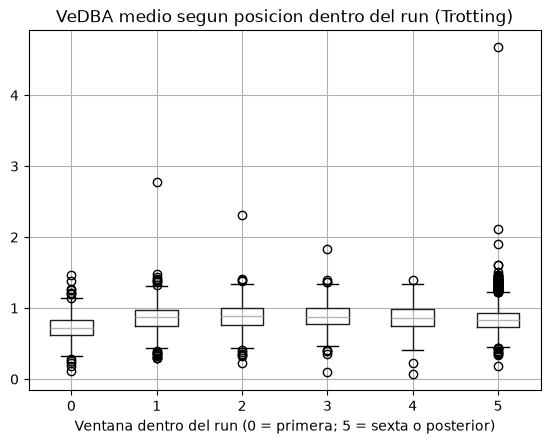

In [ ]:
# El evento de trotting, en concreto, para el vedba, tiene outliers  notorios. Los analizamos viendo en que punto del run se da para ver si es un artefacto de la media movil

ventanas_df['pos_en_run'] = ventanas_df.groupby('run_id').cumcount()

trotting = ventanas_df[ventanas_df['behavior'] == 'Trotting'].copy()
trotting['pos_en_run_capado'] = trotting['pos_en_run'].clip(upper=5)

trotting.boxplot(column='vedba_mean', by='pos_en_run_capado')
plt.title('VeDBA medio segun posicion dentro del run (Trotting)')
plt.suptitle('')
plt.xlabel('Ventana dentro del run (0 = primera; 5 = sexta o posterior)')
plt.show()

# La grafica indica que los outliers no son un artefacto de la media movil (como el primer dato de la media no tiene un valor previo, es el mismo), sino que es un dato real. 
# Aun asi, la primera ventana calculada esta subestimada por el propio calculo de la media, por lo que se descarta para los siguientes pasos.

In [15]:
ventanas_df = ventanas_df[ventanas_df['pos_en_run'] > 0].reset_index(drop=True)

print(f"Ventanas tras descartar la primera de cada run: {len(ventanas_df)}")
print()
print("Ventanas por clase:")
print(ventanas_df['behavior'].value_counts())

Ventanas tras descartar la primera de cada run: 33126

Ventanas por clase:
behavior
Lying chest    10980
Standing        9365
Trotting        6518
Walking         6263
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score

FEATURES = ['vedba_mean', 'vedba_max', 'pitch_mean', 'roll_mean']
CLASES = ['Lying chest', 'Standing', 'Trotting', 'Walking']

X = ventanas_df[FEATURES].to_numpy()
y = ventanas_df['behavior'].to_numpy()
grupos = ventanas_df['dog_id'].to_numpy()

logo = LeaveOneGroupOut()
print(f"Numero de perros: {logo.get_n_splits(groups=grupos)}")

Numero de perros: 45


In [ ]:
y_true_total = []       # etiquetas reales, acumuladas de los 45 perros
y_pred_mlp_total = []   # predicciones del MLP, acumuladas de los 45 perros
y_pred_logreg_total = []  # predicciones de la Regresion Logistica (baseline), acumuladas
dog_id_total = []
n_iter_por_perro = []

# logo.split(...) genera 45 pares (idx_train, idx_test): en cada vuelta,
# idx_test son las posiciones de las ventanas de UN perro, idx_train las
# del resto (44 perros). Se repite una vez por cada perro distinto.
for idx_train, idx_test in logo.split(X, y, groups=grupos):

    # separamos features y etiquetas de este perro concreto (44 perros para entrenar, 1 perro excluido para evaluar)
    X_train, X_test = X[idx_train], X[idx_test]
    y_train, y_test = y[idx_train], y[idx_test]

    # Escalador nuevo en cada vuelta (no reutilizar uno de fuera del bucle, o arrastraria el ajuste del perro anterior
    escalador = StandardScaler()

    # fit_transform: calcula media y desviacion tipica de cada feature usando SOLO estos 44 perros, y transforma esos mismos datos
    X_train_esc = escalador.fit_transform(X_train)

    # transform (sin fit): aplica esa misma media/desviacion, ya fija, al perro de test (nunca se recalcula con sus datos)
    X_test_esc = escalador.transform(X_test)

    # MLP: una sola capa oculta de 16 neuronas (arquitectura sencilla)
    modelo_mlp = MLPClassifier(
        hidden_layer_sizes=(16,),   # 1 capa oculta, 16 neuronas
        activation='relu',           # activacion estandar en la capa oculta
        solver='adam',               # optimizador robusto, sin ajustar learning rate a mano
        early_stopping=True,         # reserva parte del train como validacion interna
        n_iter_no_change=15,         # si 15 iteraciones seguidas no mejoran
        max_iter=500,                # tope maximo de iteraciones si no salta el early stopping
        random_state=42,             # semilla fija, para que sea reproducible
    )
    modelo_mlp.fit(X_train_esc, y_train)  # entrena con las features normalizadas
    n_iter_por_perro.append(modelo_mlp.n_iter_)

    # Regresion Logistica: mismo patron de entrenamiento,
    # modelo mucho mas simple (fronteras lineales, sin capa oculta)
    modelo_logreg = LogisticRegression(max_iter=1000, random_state=42)
    modelo_logreg.fit(X_train_esc, y_train)

    # Acumulamos: etiquetas reales del perro excluido, y lo que predice
    # cada modelo para ese mismo perro (nunca visto durante su entrenamiento).
    # extend() porque predict() devuelve varias predicciones (una por ventana
    # del perro), no un unico valor - append() las meteria como una lista anidada
    y_true_total.extend(y_test)
    y_pred_mlp_total.extend(modelo_mlp.predict(X_test_esc))
    y_pred_logreg_total.extend(modelo_logreg.predict(X_test_esc))
    dog_id_total.extend(grupos[idx_test])


print("Entrenamiento completo (MLP + Regresion Logistica)")
print()
print(f"Iteraciones hasta parar (min/media/max): {min(n_iter_por_perro)} / {sum(n_iter_por_perro)/len(n_iter_por_perro):.1f} / {max(n_iter_por_perro)}")
print(f"Perros que llegaron al tope de 500 iteraciones: {sum(1 for n in n_iter_por_perro if n >= 500)}")

Entrenamiento completo (MLP + Regresion Logistica)

Iteraciones hasta parar (min/media/max): 25 / 40.0 / 103
Perros que llegaron al tope de 500 iteraciones: 0


In [18]:
print("=== MLP ===")
print(classification_report(y_true_total, y_pred_mlp_total, labels=CLASES))
print(f"F1-macro MLP: {f1_score(y_true_total, y_pred_mlp_total, labels=CLASES, average='macro'):.3f}")

print()
print("=== Regresion Logistica (baseline) ===")
print(classification_report(y_true_total, y_pred_logreg_total, labels=CLASES))
print(f"F1-macro Regresion Logistica: {f1_score(y_true_total, y_pred_logreg_total, labels=CLASES, average='macro'):.3f}")

=== MLP ===
              precision    recall  f1-score   support

 Lying chest       0.72      0.71      0.72     10980
    Standing       0.67      0.67      0.67      9365
    Trotting       0.99      0.99      0.99      6518
     Walking       0.93      0.97      0.95      6263

    accuracy                           0.80     33126
   macro avg       0.83      0.83      0.83     33126
weighted avg       0.80      0.80      0.80     33126

F1-macro MLP: 0.832

=== Regresion Logistica (baseline) ===
              precision    recall  f1-score   support

 Lying chest       0.72      0.77      0.74     10980
    Standing       0.72      0.64      0.67      9365
    Trotting       0.99      0.98      0.99      6518
     Walking       0.93      0.98      0.95      6263

    accuracy                           0.81     33126
   macro avg       0.84      0.84      0.84     33126
weighted avg       0.81      0.81      0.81     33126

F1-macro Regresion Logistica: 0.840


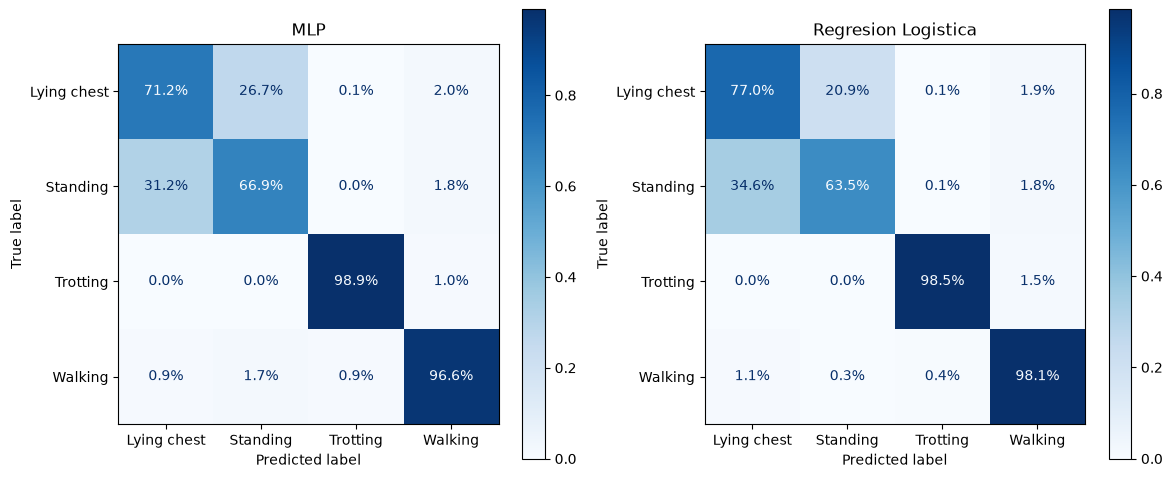

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_true_total, y_pred_mlp_total, labels=CLASES,
    normalize='true', values_format='.1%', cmap='Blues', ax=axes[0],
)
axes[0].set_title('MLP')

ConfusionMatrixDisplay.from_predictions(
    y_true_total, y_pred_logreg_total, labels=CLASES,
    normalize='true', values_format='.1%', cmap='Blues', ax=axes[1],
)
axes[1].set_title('Regresion Logistica')

plt.tight_layout()
plt.show()

In [20]:
from sklearn.pipeline import make_pipeline
import joblib

FEATURES = ['vedba_mean', 'vedba_max', 'pitch_mean', 'roll_mean']

X_completo = ventanas_df[FEATURES].to_numpy()
y_completo = ventanas_df['behavior'].to_numpy()

modelo_final = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(16,),
        activation='relu',
        solver='adam',
        early_stopping=True,
        n_iter_no_change=15,
        max_iter=500,
        random_state=42,
    ),
)
modelo_final.fit(X_completo, y_completo)

joblib.dump(modelo_final, 'modelo_comportamiento.joblib')
print("Modelo guardado en modelo_comportamiento.joblib")

Modelo guardado en modelo_comportamiento.joblib


In [21]:
import time

ejemplo = X_completo[:1]  # una sola ventana, forma (1, 4)

n_repeticiones = 1000
inicio = time.perf_counter()
for _ in range(n_repeticiones):
    modelo_final.predict(ejemplo)
fin = time.perf_counter()

tiempo_medio_ms = (fin - inicio) / n_repeticiones * 1000
print(f"Tiempo medio por prediccion individual: {tiempo_medio_ms:.3f} ms")

Tiempo medio por prediccion individual: 0.362 ms


In [22]:
mlp = modelo_final.named_steps['mlpclassifier']

print(f"Iteraciones hasta la convergencia: {mlp.n_iter_}")
print(f"Mejor score de validacion interna (early_stopping): {mlp.best_validation_score_:.3f}")

Iteraciones hasta la convergencia: 35
Mejor score de validacion interna (early_stopping): 0.835


In [23]:
import os

n_params = sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)
tam_kb = os.path.getsize('modelo_comportamiento.joblib') / 1024

print(f"Parametros del MLP (pesos + sesgos): {n_params}")
print(f"Tamano del archivo serializado: {tam_kb:.1f} KB")

Parametros del MLP (pesos + sesgos): 148
Tamano del archivo serializado: 12.7 KB
